# 02 - Dataset de demanda y modelo de aceptación

## Fase 3 -- Construcción del dataset de demanda

Unimos `accepted` (`acepto_prestamo = 1`) y `rejected` (`acepto_prestamo = 0`) en un único dataset, usando el mapeo de columnas documentado en `notebooks/01_eda.ipynb` e implementado en `src/preprocessing.build_demand_dataset`.

**Limitación metodológica (ya introducida en el README, se repite aquí porque es central para todo lo que sigue):** en `rejected` no siempre se distingue si fue el *cliente* quien rechazó una oferta o el *banco* quien rechazó la solicitud antes de llegar a ofertar nada. Phillips (2013) define `F̄_i(r)` como la fracción de solicitantes *que ya pasaron underwriting* que acepta la tasa `r`. Nuestra variable `acepto_prestamo` es un proxy razonable de eso -- toda fila de `accepted` sí pasó underwriting y aceptó; toda fila de `rejected` no llegó a tener un préstamo, sin más granularidad sobre la razón -- pero no es una medición perfecta. Se documenta y se sigue adelante porque es la mejor aproximación disponible en un dataset público.

Además, `int_rate` (la tasa) solo existe para `accepted`: un rechazo nunca llega a que se le cotice una tasa. Esa asimetría se maneja explícitamente en la Fase 5 (feature engineering del modelo de demanda), no se inventa un valor aquí.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import build_demand_dataset  # noqa: E402

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (9, 4)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

accepted_clean = pd.read_csv(PROCESSED_DIR / "accepted_clean.csv.gz", low_memory=False)
rejected_clean = pd.read_csv(PROCESSED_DIR / "rejected_clean.csv.gz", low_memory=False)

print(f"accepted_clean: {accepted_clean.shape}")
print(f"rejected_clean: {rejected_clean.shape}")

accepted_clean: (149996, 155)
rejected_clean: (149993, 14)


In [2]:
demand = build_demand_dataset(accepted_clean, rejected_clean)

print(f"demand: {demand.shape}")
print()
print(demand["acepto_prestamo"].value_counts(normalize=True))
print()
demand.head()

demand: (299989, 12)

acepto_prestamo
1    0.500005
0    0.499995
Name: proportion, dtype: float64



,acepto_prestamo,monto,dti,fico,risk_score,emp_length_years,purpose,zip_code,addr_state,int_rate,fecha_solicitud,source_dataset
0,1,16000.0,26.40,722.0,NaN,1.0,debt_consolidation,786xx,TX,12.88,Dec-2015,accepted
1,1,29900.0,21.77,717.0,NaN,10.0,debt_consolidation,219xx,MD,12.88,Dec-2015,accepted
2,1,20000.0,18.83,837.0,NaN,9.0,debt_consolidation,125xx,NY,5.32,Dec-2015,accepted
3,1,16000.0,23.35,682.0,NaN,0.0,debt_consolidation,880xx,NM,17.97,Dec-2015,accepted
4,1,25000.0,34.53,732.0,NaN,9.0,debt_consolidation,212xx,MD,13.99,Dec-2015,accepted


In [3]:
print("% de missing por columna en el dataset de demanda:")
print(demand.isna().mean().sort_values(ascending=False))

% de missing por columna en el dataset de demanda:
risk_score          0.833137
fico                0.499995
int_rate            0.499995
emp_length_years    0.049598
dti                 0.000987
monto               0.000000
acepto_prestamo     0.000000
purpose             0.000000
zip_code            0.000000
addr_state          0.000000
fecha_solicitud     0.000000
source_dataset      0.000000
dtype: float64


Como es esperable por construcción: `risk_score` falta en ~83% del dataset combinado (100% de `accepted` + el 66.6% de `rejected` que ya sabíamos que faltaba), `fico` e `int_rate` faltan en ~50% (exactamente las filas de `rejected`). Esto no es un error -- es la asimetría estructural entre ambos datasets, y el modelo de demanda de la Fase 5 se diseña sabiendo esto (features presentes en ambos datasets, tratamiento explícito de missing por modelo).

In [4]:
demand.to_csv(PROCESSED_DIR / "demand_dataset.csv.gz", index=False, compression="gzip")
print("Guardado:", PROCESSED_DIR / "demand_dataset.csv.gz")

Guardado: C:\Users\josue\credit-pricing-optimizer\data\processed\demand_dataset.csv.gz


## Fase 5 -- Modelo de demanda (F̄(r) a nivel individual)

Se entrena a nivel de **cliente individual** (no por segmento, ver README) usando solo variables presentes en ambos datasets. Dos decisiones de feature engineering resuelven las asimetrías entre `accepted` y `rejected` -- documentadas en detalle en `src/demand_model.py`:

- **`risk_percentile`**: normaliza `fico` (accepted) y `risk_score` (rejected) al percentil que ocupa cada cliente *dentro de su propio dataset* (no son la misma escala, así que no se combinan como si lo fueran).
- **`tasa`**: `int_rate` real para accepted; para rejected (que nunca recibió una cotización) se estima una **tasa contrafactual** con un modelo de pricing auxiliar entrenado solo sobre accepted. Usar `int_rate` crudo con NaN en todo `rejected` haría que el modelo aprenda trivialmente "tasa faltante -> rechazado" (perfectamente correlacionado por construcción), lo cual es inservible para el objetivo real: poder evaluar la probabilidad de aceptación de cualquier perfil a distintas tasas candidatas (necesario para la Fase 6).

In [5]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

from src.demand_model import DEMAND_FEATURES, build_demand_features, demand_model_pipeline

demand_feat = build_demand_features(demand)

X = demand_feat[DEMAND_FEATURES]
y = demand_feat["acepto_prestamo"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"train: {X_train.shape}, test: {X_test.shape}")

train: (239991, 7), test: (59998, 7)


### Regresión logística (interpretable)

In [6]:
pipe_lr = demand_model_pipeline(LogisticRegression(max_iter=2000))
pipe_lr.fit(X_train, y_train)
proba_lr = pipe_lr.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, proba_lr)
brier_lr = brier_score_loss(y_test, proba_lr)
print(f"Logistic Regression -- AUC: {auc_lr:.4f} | Brier: {brier_lr:.4f}")

Logistic Regression -- AUC: 0.8996 | Brier: 0.1304


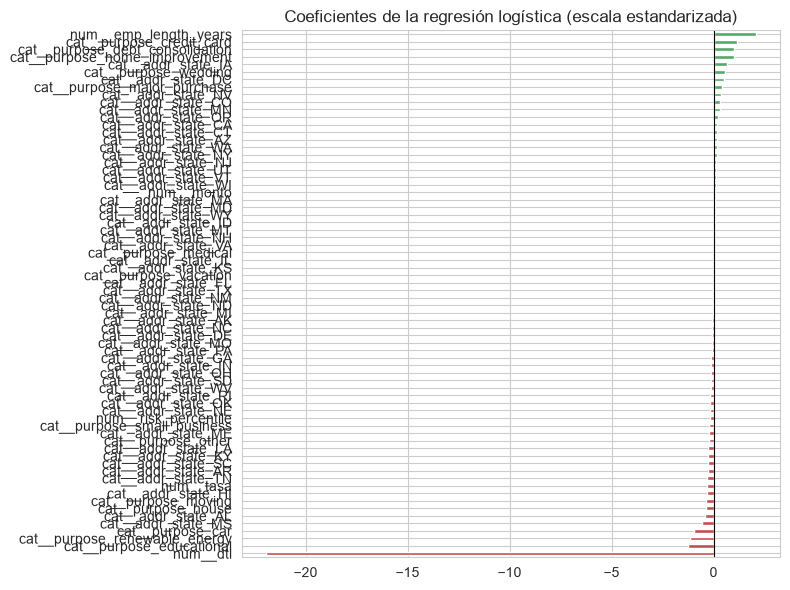

In [7]:
feature_names = pipe_lr.named_steps["preprocess"].get_feature_names_out()
coefs = pd.Series(pipe_lr.named_steps["model"].coef_[0], index=feature_names).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
coefs.plot(kind="barh", ax=ax, color=["#C44E52" if c < 0 else "#55A868" for c in coefs])
ax.set_title("Coeficientes de la regresión logística (escala estandarizada)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

**Lectura de negocio:** `num__tasa` tiene coeficiente negativo (-0.31), como debía ser: a mayor tasa ofrecida, menor probabilidad de aceptación. Es la relación de demanda básica que todo el proyecto necesita para que la optimización de la Fase 8 tenga sentido -- si `tasa` no fuera negativa, subir la tasa nunca costaría demanda y el problema de pricing sería trivial.

**Hallazgo no anticipado:** `num__risk_percentile` también sale negativo (-0.19), no positivo como intuitivamente se esperaría (mayor percentil = perfil de *menor* riesgo relativo dentro de su propio dataset = debería ser más fácil de aprobar). La explicación es la limitación que ya se documentó al construir el feature: `risk_percentile` se calcula *dentro de cada dataset por separado* (percentil entre accepted, percentil entre rejected), así que **no es comparable entre grupos**. Un solicitante rechazado con `risk_percentile=90` (el mejor percentil relativo *dentro del pool de rechazados*) puede seguir siendo, en términos absolutos, más riesgoso que un cliente aceptado con `risk_percentile=10` (el peor percentil relativo *dentro del pool de aceptados*, pero aun así suficientemente bueno para ser aprobado). El coeficiente termina capturando en buena parte esta mezcla de escalas, no una relación de riesgo pura. Se documenta como limitación conocida del feature -- no se corrige en este proyecto porque no existe una escala verdaderamente común entre `fico` y `Risk_Score` en los datos originales (ver mapeo de columnas en `01_eda.ipynb`).

### XGBoost (performance)

In [8]:
pipe_xgb = demand_model_pipeline(
    XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42, eval_metric="logloss"
    )
)
pipe_xgb.fit(X_train, y_train)
proba_xgb = pipe_xgb.predict_proba(X_test)[:, 1]

auc_xgb = roc_auc_score(y_test, proba_xgb)
brier_xgb = brier_score_loss(y_test, proba_xgb)
print(f"XGBoost -- AUC: {auc_xgb:.4f} | Brier: {brier_xgb:.4f}")

XGBoost -- AUC: 0.9965 | Brier: 0.0218


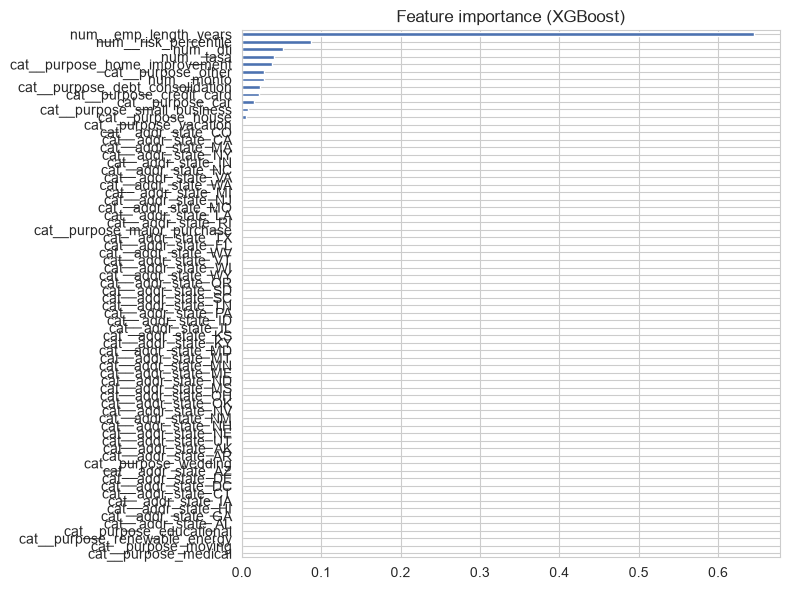

In [9]:
importances = pd.Series(
    pipe_xgb.named_steps["model"].feature_importances_, index=feature_names
).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Feature importance (XGBoost)")
plt.tight_layout()
plt.show()

### Calibración de probabilidades -- **crítico para este proyecto**

AUC-ROC solo mide qué tan bien el modelo *ordena* clientes por riesgo/probabilidad relativa, no si el número que produce (ej. "0.73 de probabilidad de aceptar") es correcto en términos absolutos. El optimizador de la Fase 8 usa las `p_{i,k}` (probabilidad de aceptación agregada por sub_grade y tasa candidata) **directamente en la función objetivo** -- si esas probabilidades individuales están mal calibradas, la utilidad esperada que el optimizador cree estar maximizando está sesgada, aunque el modelo "ordene bien" a los clientes. Por eso se evalúa calibración explícitamente, no solo AUC.

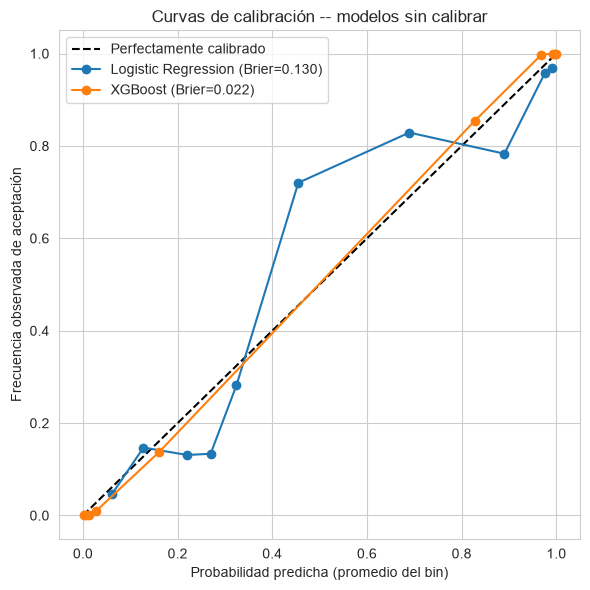

In [10]:
frac_lr, mean_lr = calibration_curve(y_test, proba_lr, n_bins=10, strategy="quantile")
frac_xgb, mean_xgb = calibration_curve(y_test, proba_xgb, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", label="Perfectamente calibrado")
ax.plot(mean_lr, frac_lr, marker="o", label=f"Logistic Regression (Brier={brier_lr:.3f})")
ax.plot(mean_xgb, frac_xgb, marker="o", label=f"XGBoost (Brier={brier_xgb:.3f})")
ax.set_xlabel("Probabilidad predicha (promedio del bin)")
ax.set_ylabel("Frecuencia observada de aceptación")
ax.set_title("Curvas de calibración -- modelos sin calibrar")
ax.legend()
plt.tight_layout()
plt.show()

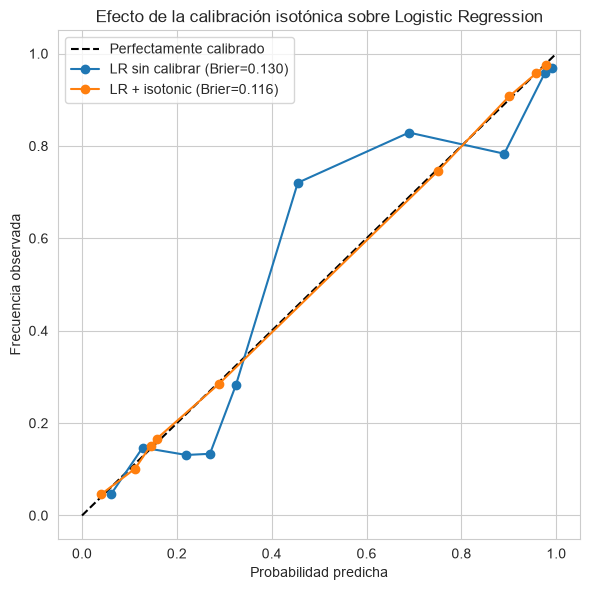

Brier LR sin calibrar: 0.1304 -> con isotonic: 0.1157


In [11]:
# Isotonic regression sobre la Logistic Regression (la que más lo necesita, ver curva arriba)
calibrated_lr = CalibratedClassifierCV(pipe_lr, method="isotonic", cv=5)
calibrated_lr.fit(X_train, y_train)
proba_lr_cal = calibrated_lr.predict_proba(X_test)[:, 1]
brier_lr_cal = brier_score_loss(y_test, proba_lr_cal)

frac_lr_cal, mean_lr_cal = calibration_curve(y_test, proba_lr_cal, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", label="Perfectamente calibrado")
ax.plot(mean_lr, frac_lr, marker="o", label=f"LR sin calibrar (Brier={brier_lr:.3f})")
ax.plot(
    mean_lr_cal, frac_lr_cal, marker="o", label=f"LR + isotonic (Brier={brier_lr_cal:.3f})"
)
ax.set_xlabel("Probabilidad predicha")
ax.set_ylabel("Frecuencia observada")
ax.set_title("Efecto de la calibración isotónica sobre Logistic Regression")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Brier LR sin calibrar: {brier_lr:.4f} -> con isotonic: {brier_lr_cal:.4f}")

### Selección del modelo final

XGBoost gana en las dos dimensiones que importan para este proyecto: mejor AUC (mejor discriminación) y curva de calibración ya cercana a la diagonal *sin necesidad de post-calibración* (Brier bajo desde el modelo base). Se usa como el modelo de demanda final -- es el que alimenta la Fase 6 (curvas de elasticidad por sub_grade) y, agregado, la función objetivo del optimizador en la Fase 8.

Se guarda el pipeline completo (preprocesamiento + modelo) para reusarlo sin tener que reentrenar.

In [12]:
import joblib

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(pipe_xgb, MODELS_DIR / "demand_model.joblib")

print("Modelo de demanda guardado en:", MODELS_DIR / "demand_model.joblib")
print()
print("Resumen de métricas:")
print(f"  Logistic Regression -- AUC={auc_lr:.4f}  Brier={brier_lr:.4f}  Brier (isotonic)={brier_lr_cal:.4f}")
print(f"  XGBoost (elegido)   -- AUC={auc_xgb:.4f}  Brier={brier_xgb:.4f}")

Modelo de demanda guardado en: C:\Users\josue\credit-pricing-optimizer\models\demand_model.joblib

Resumen de métricas:
  Logistic Regression -- AUC=0.8996  Brier=0.1304  Brier (isotonic)=0.1157
  XGBoost (elegido)   -- AUC=0.9965  Brier=0.0218


## Resumen y próximos pasos

- Dataset de demanda construido (Fase 3) y modelo de demanda entrenado a nivel individual (Fase 5), con calibración de probabilidades evaluada explícitamente (crítico porque el optimizador usa `p` directamente en la función objetivo).
- `risk_percentile` resuelve la comparación de riesgo entre escalas distintas (fico vs. Risk_Score); `tasa` resuelve la ausencia estructural de tasa ofrecida en `rejected` vía un modelo de pricing contrafactual entrenado sobre `accepted`.
- Modelo final: XGBoost, guardado en `models/demand_model.joblib`.
- Próximo notebook: `03_risk_estimation.ipynb` -- modelos individuales de PD y LGD, y el supuesto de costo de fondeo (Fase 7).
- Luego: `04_aggregation_subgrade.ipynb` -- agregación de p, PD, LGD a nivel de sub_grade y curvas de elasticidad por segmento (Fases 4 y 6).